# Q-Learning on Star Graph (MonteKarloPairGame)
Experiment setup:
- 15 Nodes (Star Graph)
- Q-Learning Agents
- MonteKarloPairGame
- PPReward Model (b=3.0, c=1.0)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import sys
import os

# Ensure current directory is in path
sys.path.append(os.getcwd())

from graph_structure import StarGraph, WheelGraph, SmallWorldGraph
from learner import QLearner
from reward_model import PPReward
from game_launcher import MonteKarloPairGame

%matplotlib inline

In [3]:
# Configuration
N_NODES = 100
B = list(range(1, 10))  # Benefit values to sweep
C = 1.0
K_ANCHORS = 1
N_EPISODES= 1000
N_EXPS = 100

# Initialization
graph = StarGraph(N_NODES)
# Note: Learners here are just for initial setup/testing, meaningful learners are created in the loop
learners = [QLearner(action_space_size=2, learning_rate=0.2, discount_factor=0.99, strategy='boltzmann') for _ in range(N_NODES)]

In [4]:
# Training Loop
from tqdm import tqdm

all_cooperation_rates = np.zeros((len(B), N_EXPS, N_EPISODES))
for j in range(len(B)):   
    cooperation_rates = np.zeros((N_EXPS, N_EPISODES))
    current_reward_model = PPReward(b=B[j], c=C)
    
    for i in tqdm(range(N_EXPS)):
        # Fix: Re-initialize learners for each experiment to ensure they are independent
        # otherwise they share state/Q-tables across experiments
        current_learners = [QLearner(action_space_size=2, learning_rate=0.2, discount_factor=0.9, strategy='boltzmann') for _ in range(N_NODES)]
        
        # Initialize new game instance
        game = MonteKarloPairGame(graph, current_learners, current_reward_model, k_anchors=K_ANCHORS)
        
        for episode in range(N_EPISODES):
            game.round()
            coop_rate = np.mean(game.strategies)
            cooperation_rates[i, episode] = coop_rate

    all_cooperation_rates[j] = cooperation_rates

print("Training Complete")

  9%|▉         | 9/100 [00:05<00:58,  1.57it/s]


KeyboardInterrupt: 

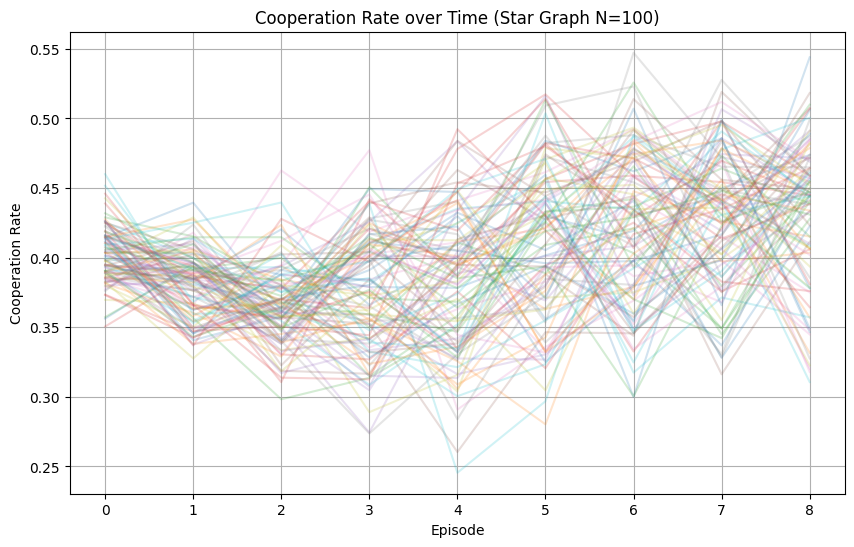

In [ ]:
# Visualization
plt.figure(figsize=(10, 6))
plt.plot(np.mean(all_cooperation_rates, axis=2), alpha = 0.2)
plt.title(f'Cooperation Rate over Time (Star Graph N={N_NODES})')
plt.xlabel('Episode')
plt.ylabel('Cooperation Rate')
plt.grid(True)
plt.show()

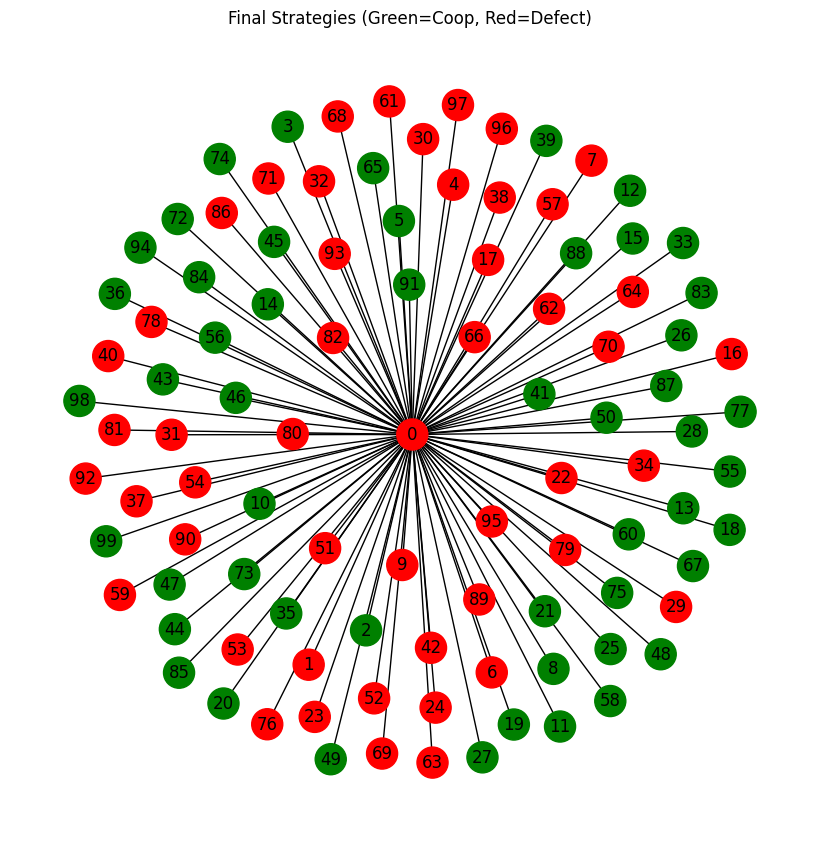

In [ ]:
# Final Strategies Visualization
G = graph.G
pos = nx.spring_layout(G)
colors = ['green' if s == 1 else 'red' for s in game.strategies]

plt.figure(figsize=(8, 8))
nx.draw(G, pos, node_color=colors, with_labels=True, node_size=500)
plt.title("Final Strategies (Green=Coop, Red=Defect)")
plt.show()

In [7]:
# Configuration
N_NODES = 100
# B = list(range(1, 6, 2))  # Benefit values to sweep
B = [3]
C = 1.0
K_ANCHORS = 1
N_EPISODES= 4000
N_EXPS = 100

# Initialization
graph = SmallWorldGraph(N_NODES, k=4, p=0.1)
# Note: Learners here are just for initial setup/testing, meaningful learners are created in the loop
learners = [QLearner(action_space_size=2, learning_rate=0.2, discount_factor=0.9, strategy='boltzmann') for _ in range(N_NODES)]

In [9]:
# Training Loop
from tqdm import tqdm

all_cooperation_rates = np.zeros((len(B), N_EXPS, N_EPISODES))
for j in range(len(B)):   
    cooperation_rates = np.zeros((N_EXPS, N_EPISODES))
    current_reward_model = PPReward(b=B[j], c=C)
    
    for i in tqdm(range(N_EXPS)):
        # Fix: Re-initialize learners for each experiment to ensure they are independent
        # otherwise they share state/Q-tables across experiments
        current_learners = [QLearner(action_space_size=2, learning_rate=0.2, discount_factor=0.99, temperature=2.0, strategy='boltzmann') for _ in range(N_NODES)]
        
        # Initialize new game instance
        game = MonteKarloPairGame(graph, current_learners, current_reward_model, k_anchors=K_ANCHORS)
        
        for episode in range(N_EPISODES):
            game.round()
            coop_rate = np.mean(game.strategies)
            cooperation_rates[i, episode] = coop_rate

    all_cooperation_rates[j] = cooperation_rates

print("Training Complete")

100%|██████████| 100/100 [04:24<00:00,  2.64s/it]

Training Complete


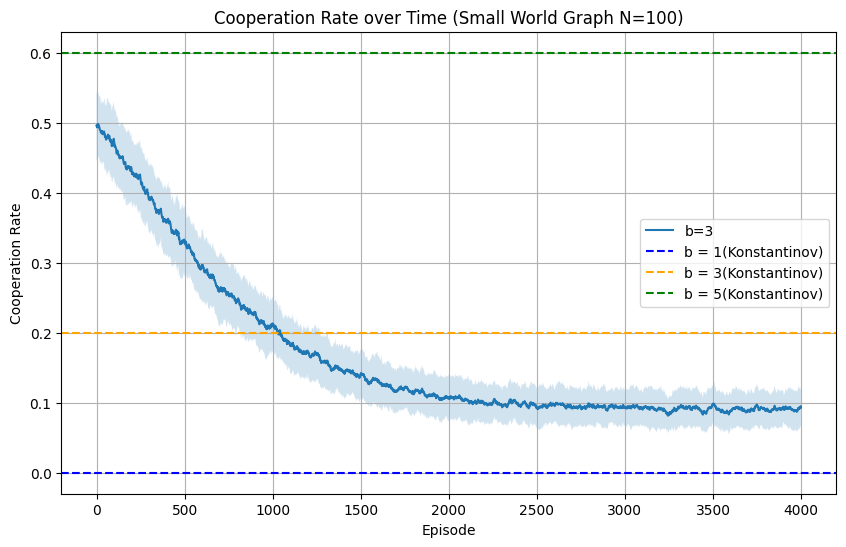

In [10]:
# Visualization
plt.figure(figsize=(10, 6))

# Plot mean and std for each B (benefit value)
for j, b in enumerate(B):
    # Calculate mean and std over experiments (axis 1)
    mean_trace = np.mean(all_cooperation_rates[j], axis=0)
    std_trace = np.std(all_cooperation_rates[j], axis=0)
    
    # Plot mean line
    plt.plot(mean_trace, label=f'b={b}')
    # Fill area between mean +/- std
    plt.fill_between(range(N_EPISODES), mean_trace - std_trace, mean_trace + std_trace, alpha=0.2)

plt.axline((0, 0), (N_EPISODES, 0), color='blue', linestyle='--', label='b = 1(Konstantinov)')
plt.axline((0, 0.2), (N_EPISODES, 0.2), color='orange', linestyle='--', label='b = 3(Konstantinov)')
plt.axline((0, 0.6), (N_EPISODES, 0.6), color='green', linestyle='--', label='b = 5(Konstantinov)')


plt.title(f'Cooperation Rate over Time (Small World Graph N={N_NODES})')
plt.xlabel('Episode')
plt.ylabel('Cooperation Rate')
plt.legend()
plt.grid(True)
plt.show()